In [66]:
!python --version


Python 3.12.12


Importing the necessary libraries

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms,models,datasets
import torch.optim as optim
from torch.utils.data import DataLoader,random_split
import warnings
warnings.filterwarnings('ignore')

In [37]:
print(torch.__version__)
print(np.__version__)

2.8.0+cu126
2.0.2


In [38]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [39]:
torch.manual_seed(245)

In [1]:
# !unzip Plant_Village_Dataset.zip

Getting to know the dataset and performoing some transformation.

In [65]:
import os
count = 0
dirs = os.listdir('/content/Plant Village Dataset/')
for dir in dirs:
    files = list(os.listdir('/content/Plant Village Dataset/'+dir))
    print( dir +' Folder has '+ str(len(files)) + ' images')
    count = count + len(files)
print( 'Folder has '+ str(count) + ' images')

Potato___Late_blight Folder has 1000 images
Potato___Early_blight Folder has 1000 images
Potato___healthy Folder has 152 images
Folder has 2152 images


In [42]:
data_transforms = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor(),
 ])

In [43]:
full_dataset = datasets.ImageFolder(root = "/content/Plant Village Dataset",transform = data_transforms)

In [44]:
train_ratio = 0.80
val_ratio = 0.20

In [45]:
dataset_size = len(full_dataset)
train_size = int(train_ratio*dataset_size)
val_size = dataset_size - train_size

In [46]:
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [47]:
len(full_dataset)

2152

In [48]:
len(train_dataset)

1721

In [49]:
len(val_dataset)

431

In [50]:
batch_size = 32
train_loader = DataLoader(train_dataset,batch_size = batch_size,shuffle = True,pin_memory = True)
val_loader = DataLoader(val_dataset,batch_size = batch_size,shuffle = False,pin_memory = True)

In [51]:
class_names= full_dataset.classes
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

Building the Model

In [52]:
class LeafCNN(nn.Module):
  def __init__(self,num_classes):
    super().__init__()

    self.features = nn.Sequential(
        nn.Conv2d(3,32,3, padding='same'),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(32,64,3, padding='same'),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(64,64,3, padding='same'),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(64,64,3, padding='same'),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(64,64,3, padding='same'),
        nn.ReLU(),
        nn.MaxPool2d(2),
         nn.Conv2d(64,64,3, padding='same'),
        nn.ReLU(),
        nn.MaxPool2d(2)
         )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(1024,64),
        nn.ReLU(),
        nn.Linear(64,3)
    )

  def forward(self,x):
    x = self.features(x)
    x = self.classifier(x)
    return x


In [53]:
epochs = 20
num_classes = 3

model = LeafCNN(num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [54]:
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features,batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    output = model(batch_features)
    loss = criterion(output,batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss = total_epoch_loss + loss.item()
  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 0.9362967411677042
Epoch: 2 , Loss: 0.8624836482383587
Epoch: 3 , Loss: 0.5591982939728984
Epoch: 4 , Loss: 0.42958170341120827
Epoch: 5 , Loss: 0.372264060985159
Epoch: 6 , Loss: 0.29802115123581
Epoch: 7 , Loss: 0.25725497001851044
Epoch: 8 , Loss: 0.20336647814622633
Epoch: 9 , Loss: 0.1552637721998272
Epoch: 10 , Loss: 0.10910232687644937
Epoch: 11 , Loss: 0.07345866418823048
Epoch: 12 , Loss: 0.10712437697306827
Epoch: 13 , Loss: 0.13281618252707025
Epoch: 14 , Loss: 0.08306561612213652
Epoch: 15 , Loss: 0.04643562216208213
Epoch: 16 , Loss: 0.05351628710007019
Epoch: 17 , Loss: 0.02755727176231125
Epoch: 18 , Loss: 0.08541150591594891
Epoch: 19 , Loss: 0.02844505569319827
Epoch: 20 , Loss: 0.017626322637187077


In [55]:
model.eval()

LeafCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (16): ReLU()
    (

In [56]:
total = 0
correct = 0
with torch.no_grad():
  for batch_features, batch_labels in val_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9907192575406032


In [57]:
total = 0
correct = 0
with torch.no_grad():
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9970947123765252


Function to run prediction on sample data

In [58]:
def predict_image(img, model):
    # Convert to a batch of 1
    xb = img.unsqueeze(0).to(device)
    # Get predictions from model
    yb = model(xb).to(device)
    # Pick index with highest probability
    _, preds  = torch.max(yb, dim=1)
    # Retrieve the class label
    return full_dataset.classes[preds[0].item()]

Actual label: Potato___Late_blight
Predicted label: Potato___Late_blight


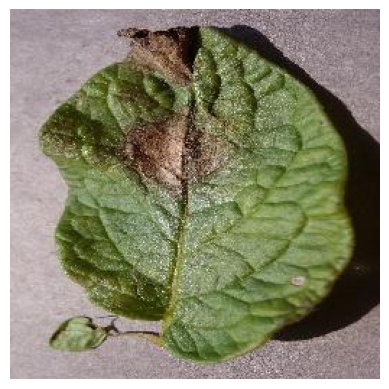

In [59]:
img,label = val_dataset[34]
img = np.clip(img, 0, 1)
plt.imshow(img.permute(1,2,0))
plt.axis('off')
print('Actual label:',full_dataset.classes[label])
print('Predicted label:',predict_image(img,model))

Actual label: Potato___Early_blight
Predicted label: Potato___Early_blight


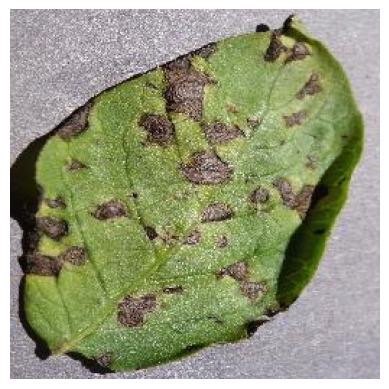

In [60]:
img,label = val_dataset[236]
img = np.clip(img, 0, 1)
plt.imshow(img.permute(1,2,0))
plt.axis('off')
print('Actual label:',full_dataset.classes[label])
print('Predicted label:',predict_image(img,model))

Actual label: Potato___Early_blight
Predicted label: Potato___Early_blight


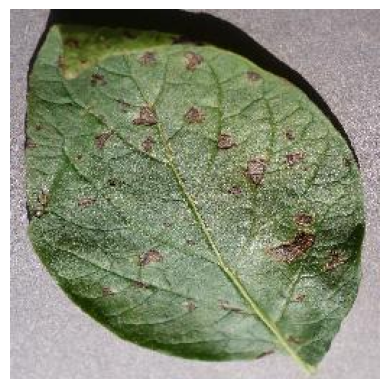

In [61]:
img,label = val_dataset[9]
img = np.clip(img, 0, 1)
plt.imshow(img.permute(1,2,0))
plt.axis('off')
print('Actual label:',full_dataset.classes[label])
print('Predicted label:',predict_image(img,model))

In [62]:
# torch.save(model,'leaf_model.pth')

In [63]:
# torch.save(model.state_dict(), "model.pth")

In [64]:
model.eval()
example_input = torch.randn(32, 3, 256, 256).to(device)  # batch_size=32, channels=3, height=256, width=256
traced_model = torch.jit.trace(model, example_input)
traced_model.save("model_traced.pt")
